# Agente vendedor con Q-learning en Mesa

**Objetivo:** aprender qu? intervenci?n comercial maximiza el retorno neto de una campa?a con presupuesto limitado. Este notebook contiene el simulador Mesa, la implementaci?n expl?cita de Q-learning, el dataset de transiciones en memoria, las pol?ticas y toda la evaluaci?n. Se ejecuta de arriba abajo en Google Colab.

**Ejecuci?n:** Runtime ? Run all. La primera celda instala Mesa; no requiere credenciales, servicios externos ni archivos adicionales. Para entregar el CSV, al final se incluye una instrucci?n de exportaci?n opcional.

In [3]:
%pip install -q "mesa>=3.5,<4"

import math
import itertools
from collections import defaultdict
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

print("Mesa:", mesa.__version__)

Note: you may need to restart the kernel to use updated packages.


c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mesa: 3.5.1


## 1. Simulador de clientes en Mesa

Se conserva el modelo del profesor: clientes con perfiles observables, arquetipos internos ocultos, fuentes de tr?fico, dinero, confianza, engagement y molestia. Cada cliente responde a la acci?n del vendedor mediante el m?todo BuyerAgent.react(). El entorno de aprendizaje que aparece despu?s usa este mismo agente Mesa; no inventa compras fuera del simulador.

**Importante:** el arquetipo, los rasgos de personalidad, el dinero y la confianza internos influyen en la simulaci?n, pero nunca se entregan a la pol?tica para elegir una acci?n.

In [4]:


INTERACTION_COLUMNS = [
    "step",
    "buyer_id",
    "archetype",
    "preferred_source",
    "source",
    "action",
    "price",
    "effective_price",
    "purchase_probability",
    "purchased",
    "money_before",
    "money_after",
    "salary",
    "pay_period",
    "steps_to_payday",
    "trust_before",
    "trust_after",
    "engagement_before",
    "engagement_after",
    "annoyance_before",
    "annoyance_after",
]

# Fast append-only simulation logs.
# We materialize these into Pandas DataFrames only when needed.
TRANSACTION_LOG = []
INTERACTION_LOG = []

In [5]:

ARCHETYPES = {
    "Bargain Hunter": {
        "impulse": 3,
        "frugality": 5,
        "loyalty": 2,
        "curiosity": 3,
        "patience": 4,
        "sociality": 2,
        "skepticism": 3,
    },

    "Loyalist": {
        "impulse": 2,
        "frugality": 2,
        "loyalty": 5,
        "curiosity": 2,
        "patience": 4,
        "sociality": 3,
        "skepticism": 2,
    },

    "Explorer": {
        "impulse": 4,
        "frugality": 2,
        "loyalty": 2,
        "curiosity": 5,
        "patience": 3,
        "sociality": 3,
        "skepticism": 1,
    },

    "Trend Chaser": {
        "impulse": 5,
        "frugality": 1,
        "loyalty": 2,
        "curiosity": 4,
        "patience": 1,
        "sociality": 5,
        "skepticism": 1,
    },

    "Skeptic": {
        "impulse": 1,
        "frugality": 4,
        "loyalty": 2,
        "curiosity": 2,
        "patience": 5,
        "sociality": 1,
        "skepticism": 5,
    },
}

TRAIT_NAMES = list(next(iter(ARCHETYPES.values())).keys())

pd.DataFrame(ARCHETYPES).T


,impulse,frugality,loyalty,curiosity,patience,sociality,skepticism
Bargain Hunter,3,5,2,3,4,2,3
Loyalist,2,2,5,2,4,3,2
Explorer,4,2,2,5,3,3,1
Trend Chaser,5,1,2,4,1,5,1
Skeptic,1,4,2,2,5,1,5


In [6]:

COUNTRY_REGIONS = {
    "United States": [
        "California", "Texas", "New York", "Florida"
    ],
    "Canada": [
        "Ontario", "Quebec", "British Columbia", "Alberta"
    ],
    "Germany": [
        "Bavaria", "Berlin", "Hesse", "North Rhine-Westphalia"
    ],
    "United Kingdom": [
        "England", "Scotland", "Wales", "Northern Ireland"
    ],
    "Mexico": [
        "Ciudad de México", "Jalisco", "Nuevo León", "Puebla"
    ],
    "Brazil": [
        "São Paulo", "Rio de Janeiro", "Minas Gerais", "Paraná"
    ],
    "Colombia": [
        "Bogotá", "Antioquia", "Valle del Cauca", "Atlántico"
    ],
    "India": [
        "Maharashtra", "Delhi", "Karnataka", "Tamil Nadu"
    ],
}

# Available money distributions.
# These are deliberately overlapping ranges rather than deterministic labels.
COUNTRY_MONEY_RANGES = {
    "United States": (180, 650),
    "Canada": (170, 600),
    "Germany": (170, 600),
    "United Kingdom": (160, 580),
    "Mexico": (90, 360),
    "Brazil": (80, 330),
    "Colombia": (75, 300),
    "India": (70, 290),
}


# Synthetic salary distributions used by the simulation.
# Buyers receive salary periodically so long simulations do not
# collapse simply because every wallet eventually reaches zero.
COUNTRY_SALARY_RANGES = {
    "United States": (120, 260),
    "Canada": (110, 240),
    "Germany": (110, 240),
    "United Kingdom": (100, 230),
    "Mexico": (60, 150),
    "Brazil": (55, 140),
    "Colombia": (50, 130),
    "India": (45, 120),
}

SOURCE_TYPES = [
    "Search",
    "Organic",
    "Email",
    "Display",
    "Facebook",
]


In [7]:

NO_ACTION = "NO_ACTION"
SEND_DISCOUNT = "SEND_DISCOUNT"
RECOMMEND_PRODUCT = "RECOMMEND_PRODUCT"
LOYALTY_REWARD = "LOYALTY_REWARD"

SELLER_ACTIONS = [
    NO_ACTION,
    SEND_DISCOUNT,
    RECOMMEND_PRODUCT,
    LOYALTY_REWARD,
]


In [8]:

class SourceAgent(mesa.Agent):

    def __init__(self, model, source_type):
        super().__init__(model)
        self.source_type = source_type


In [9]:
class BuyerAgent(mesa.Agent):
    """
    Simulated e-commerce customer.

    Observable profile fields resemble the customer attributes used elsewhere in
    the course. A hidden archetype and noisy personality traits determine how the
    customer reacts to different seller actions.

    Customer types used in this simulation:
      • Bargain Hunter  -> tends to react well to discounts
      • Loyalist        -> tends to react well to loyalty rewards
      • Explorer        -> tends to react well to product recommendations
      • Trend Chaser    -> tends to react well to product recommendations
      • Skeptic         -> tends to prefer little or no intervention

    The archetype is hidden from the RL seller agent. It is used only by the
    simulator to generate behavior.
    """

    def __init__(self, model):
        super().__init__(model)

        # --------------------------------------------------
        # Observable customer profile
        # --------------------------------------------------

        self.age = float(self.random.randint(18, 75))
        self.gender = self.random.choice(["F", "M"])

        self.country = self.random.choice(
            list(COUNTRY_REGIONS.keys())
        )

        self.state = self.random.choice(
            COUNTRY_REGIONS[self.country]
        )

        self.signup_month = float(
            self.random.randint(1, 12)
        )

        self.signup_day_of_week = float(
            self.random.randint(0, 6)
        )

        # Latent acquisition-channel preference.
        # It influences both archetype probability and movement in the world.
        self.preferred_source = self.random.choice(
            SOURCE_TYPES
        )

        # --------------------------------------------------
        # Hidden customer type
        # --------------------------------------------------

        self.archetype = self.choose_archetype()

        base = ARCHETYPES[self.archetype]

        self.traits = {
            trait: float(
                np.clip(
                    value + self.random.gauss(0, 0.55),
                    0,
                    5
                )
            )
            for trait, value in base.items()
        }

        # --------------------------------------------------
        # Customer finances
        # --------------------------------------------------

        low, high = COUNTRY_MONEY_RANGES[
            self.country
        ]

        self.money = round(
            self.random.uniform(low, high),
            2
        )

        salary_low, salary_high = COUNTRY_SALARY_RANGES[
            self.country
        ]

        self.salary = round(
            self.random.uniform(
                salary_low,
                salary_high
            ),
            2
        )

        # One synthetic pay cycle every 100 simulation steps.
        # Offsets are staggered so customers are paid on different steps.
        self.pay_period = 100
        self.pay_offset = self.random.randint(
            0,
            self.pay_period - 1
        )

        # --------------------------------------------------
        # Persistent internal customer state
        # --------------------------------------------------

        initial_state = {
            "Bargain Hunter": (0.45, 0.50, 0.05),
            "Loyalist":       (0.62, 0.55, 0.03),
            "Explorer":       (0.48, 0.65, 0.03),
            "Trend Chaser":   (0.42, 0.72, 0.04),
            "Skeptic":        (0.28, 0.28, 0.12),
        }

        (
            self.trust,
            self.engagement,
            self.annoyance,
        ) = initial_state[self.archetype]

        self.purchase_count = 0
        self.total_spent = 0.0

        self.hit_history = []
        self.action_history = []
        self.last_source = None

    # ------------------------------------------------------
    # Observable profile -> hidden archetype
    # ------------------------------------------------------

    def choose_archetype(self):

        weights = {
            "Bargain Hunter": 1.0,
            "Loyalist": 1.0,
            "Explorer": 1.0,
            "Trend Chaser": 1.0,
            "Skeptic": 1.0,
        }

        # Age contributes broad probabilistic clues.
        if self.age < 30:
            weights["Trend Chaser"] += 1.5
            weights["Explorer"] += 1.0

        elif self.age > 50:
            weights["Loyalist"] += 1.2
            weights["Skeptic"] += 0.9

        else:
            weights["Bargain Hunter"] += 0.4
            weights["Explorer"] += 0.3

        # Signup timing gives a mild signal.
        if self.signup_month >= 9:
            weights["Explorer"] += 0.5
            weights["Trend Chaser"] += 0.6

        elif self.signup_month <= 3:
            weights["Loyalist"] += 0.5

        # Preferred acquisition source is a stronger clue.
        if self.preferred_source == "Search":
            weights["Bargain Hunter"] += 1.2
            weights["Explorer"] += 0.8

        elif self.preferred_source == "Organic":
            weights["Explorer"] += 1.2
            weights["Skeptic"] += 0.8

        elif self.preferred_source == "Email":
            weights["Loyalist"] += 1.5
            weights["Bargain Hunter"] += 0.5

        elif self.preferred_source == "Display":
            weights["Trend Chaser"] += 1.3
            weights["Bargain Hunter"] += 0.4

        elif self.preferred_source == "Facebook":
            weights["Trend Chaser"] += 1.6
            weights["Explorer"] += 0.4

        # Weak synthetic country priors.
        if self.country in [
            "Mexico", "Brazil", "Colombia", "India"
        ]:
            weights["Bargain Hunter"] += 0.35

        if self.country in [
            "United States", "Canada", "Germany", "United Kingdom"
        ]:
            weights["Loyalist"] += 0.20

        # Small regional nudges prevent state/region from being pure noise.
        if self.state in ["California", "Berlin", "São Paulo"]:
            weights["Trend Chaser"] += 0.25

        if self.state in ["Texas", "Nuevo León", "Alberta"]:
            weights["Bargain Hunter"] += 0.20

        if self.state in ["Ontario", "England", "Bavaria"]:
            weights["Loyalist"] += 0.20

        archetypes = list(weights.keys())
        values = list(weights.values())

        return self.random.choices(
            archetypes,
            weights=values,
            k=1,
        )[0]

    # ------------------------------------------------------
    # Movement
    # ------------------------------------------------------

    def move(self):

        possible_steps = self.model.grid.get_neighborhood(
            self.pos,
            moore=False,
            include_center=False,
        )

        # Most movement remains exploratory.
        if self.random.random() < 0.70:
            new_position = self.random.choice(
                possible_steps
            )

        else:
            # Sometimes move toward the preferred acquisition source.
            target = self.model.source_positions[
                self.preferred_source
            ]

            def manhattan(pos):
                return (
                    abs(pos[0] - target[0])
                    + abs(pos[1] - target[1])
                )

            best_distance = min(
                manhattan(p)
                for p in possible_steps
            )

            best_steps = [
                p
                for p in possible_steps
                if manhattan(p) == best_distance
            ]

            new_position = self.random.choice(
                best_steps
            )

        self.model.grid.move_agent(
            self,
            new_position
        )

    # ------------------------------------------------------
    # Purchase tendency
    # ------------------------------------------------------

    def baseline_logit(self):

        t = {
            name: value / 5.0
            for name, value in self.traits.items()
        }

        personality_score = (
            0.25 * t["impulse"]
            + 0.20 * t["loyalty"]
            + 0.15 * t["curiosity"]
            + 0.10 * t["sociality"]
            + 0.10 * t["patience"]
            - 0.15 * t["skepticism"]
            - 0.05 * t["frugality"]
        )

        state_score = (
            + 0.90 * self.trust
            + 0.70 * self.engagement
            - 1.10 * self.annoyance
        )

        return (
            -2.50
            + 3.0 * personality_score
            + state_score
        )

    def action_effect(self, action):
        """
        Effect of the seller action on this customer's willingness to buy.

        The coefficients are intentionally strong enough that students can later
        observe a learned RL policy:
          Bargain Hunter -> SEND_DISCOUNT
          Explorer       -> RECOMMEND_PRODUCT
          Loyalist       -> LOYALTY_REWARD
          Trend Chaser   -> RECOMMEND_PRODUCT
          Skeptic        -> NO_ACTION
        """

        t = {
            name: value / 5.0
            for name, value in self.traits.items()
        }

        if action == SEND_DISCOUNT:
            return (
                + 1.60 * t["frugality"]
                + 0.45 * t["impulse"]
                - 0.80 * t["skepticism"]
            )

        if action == RECOMMEND_PRODUCT:
            return (
                + 1.60 * t["curiosity"]
                + 0.50 * t["impulse"]
                + 0.25 * t["sociality"]
                - 0.65 * t["skepticism"]
            )

        if action == LOYALTY_REWARD:
            return (
                + 1.80 * t["loyalty"]
                + 0.35 * t["patience"]
                - 0.30 * t["skepticism"]
            )

        # NO_ACTION can be the best treatment for highly skeptical customers.
        return (
            + 1.40 * t["skepticism"]
            + 0.30 * t["patience"]
            + 0.30 * self.annoyance
        )

    def source_effect(self):

        if self.last_source is None:
            return 0.0

        if self.last_source == self.preferred_source:
            return 0.45

        return -0.08

    def purchase_probability(self, action):

        logit = (
            self.baseline_logit()
            + self.action_effect(action)
            + self.source_effect()
        )

        return 1.0 / (
            1.0 + math.exp(-logit)
        )

    # ------------------------------------------------------
    # Internal-state reaction
    # ------------------------------------------------------

    def update_internal_state(
        self,
        action,
        purchased
    ):

        t = {
            name: value / 5.0
            for name, value in self.traits.items()
        }

        if action == SEND_DISCOUNT:
            fit = (
                + 0.75 * t["frugality"]
                + 0.25 * t["impulse"]
                - 0.60 * t["skepticism"]
            )

        elif action == RECOMMEND_PRODUCT:
            fit = (
                + 0.75 * t["curiosity"]
                + 0.25 * t["impulse"]
                - 0.55 * t["skepticism"]
            )

        elif action == LOYALTY_REWARD:
            fit = (
                + 0.85 * t["loyalty"]
                + 0.15 * t["patience"]
                - 0.35 * t["skepticism"]
            )

        else:
            # Leaving a skeptical customer alone can preserve trust.
            fit = (
                + 0.70 * t["skepticism"]
                + 0.20 * t["patience"]
            )

        if fit > 0.35:
            self.engagement += 0.10 + 0.08 * fit
            self.trust += 0.07 + 0.06 * fit
            self.annoyance -= 0.05

        elif fit < 0.05:
            self.annoyance += (
                0.10
                + 0.08 * abs(fit)
            )
            self.trust -= 0.05

        else:
            self.engagement += 0.02

        if purchased:
            self.engagement += 0.08
            self.trust += 0.05
            self.annoyance -= 0.03

        # Repeating the same intervention too often can create fatigue.
        if len(self.action_history) >= 3:

            last_three = self.action_history[-3:]

            if (
                action != NO_ACTION
                and len(set(last_three)) == 1
            ):
                self.annoyance += 0.08

        self.trust = float(
            np.clip(self.trust, 0.0, 1.0)
        )

        self.engagement = float(
            np.clip(self.engagement, 0.0, 1.0)
        )

        self.annoyance = float(
            np.clip(self.annoyance, 0.0, 1.0)
        )

    # ------------------------------------------------------
    # Long-run dynamics
    # ------------------------------------------------------

    def receive_salary(self):
        """Deposit periodic synthetic salary."""
        self.money += self.salary

    def steps_to_payday(self):
        """Return the number of simulation steps until the next payday."""

        remainder = (
            self.model.step_count
            - self.pay_offset
        ) % self.pay_period

        if remainder == 0:
            return 0

        return (
            self.pay_period
            - remainder
        )

    def decay_internal_state(self):
        """
        Slowly move relationship variables toward neutral values.

        This prevents trust, engagement, or annoyance from becoming permanently
        saturated during very long simulations.
        """

        self.trust += (
            0.01
            * (0.50 - self.trust)
        )

        self.engagement += (
            0.01
            * (0.40 - self.engagement)
        )

        self.annoyance *= 0.98

        self.trust = float(
            np.clip(self.trust, 0.0, 1.0)
        )

        self.engagement = float(
            np.clip(self.engagement, 0.0, 1.0)
        )

        self.annoyance = float(
            np.clip(self.annoyance, 0.0, 1.0)
        )

    # ------------------------------------------------------
    # Transaction
    # ------------------------------------------------------

    def transact(self, effective_price):

        global TRANSACTION_LOG

        if self.money < effective_price:
            return False

        self.money -= effective_price
        self.total_spent += effective_price
        self.purchase_count += 1

        transaction = {
            "age": self.age,
            "gender": self.gender,
            "country": self.country,
            "state": self.state,
            "traffic_source": self.last_source,
            "signup_month": self.signup_month,
            "signup_day_of_week": self.signup_day_of_week,
        }

        TRANSACTION_LOG.append(
            transaction
        )

        return True

    # ------------------------------------------------------
    # Seller action -> response -> transaction
    # ------------------------------------------------------

    def react(
        self,
        action,
        base_price=40.0
    ):

        global INTERACTION_LOG

        self.action_history.append(
            action
        )

        if action == SEND_DISCOUNT:
            effective_price = (
                base_price * 0.80
            )

        elif action == LOYALTY_REWARD:
            effective_price = (
                base_price * 0.90
            )

        else:
            effective_price = base_price

        money_before = self.money
        trust_before = self.trust
        engagement_before = self.engagement
        annoyance_before = self.annoyance

        p_purchase = (
            self.purchase_probability(
                action
            )
        )

        wants_to_buy = (
            self.random.random()
            < p_purchase
        )

        purchased = False

        if wants_to_buy:
            purchased = self.transact(
                effective_price
            )

        self.update_internal_state(
            action,
            purchased
        )

        INTERACTION_LOG.append({
            "step": self.model.step_count,
            "buyer_id": self.unique_id,
            "archetype": self.archetype,
            "preferred_source": self.preferred_source,
            "source": self.last_source,
            "action": action,
            "price": base_price,
            "effective_price": effective_price,
            "purchase_probability": p_purchase,
            "purchased": purchased,
            "money_before": money_before,
            "money_after": self.money,
            "salary": self.salary,
            "pay_period": self.pay_period,
            "steps_to_payday": self.steps_to_payday(),
            "trust_before": trust_before,
            "trust_after": self.trust,
            "engagement_before": engagement_before,
            "engagement_after": self.engagement,
            "annoyance_before": annoyance_before,
            "annoyance_after": self.annoyance,
        })

        return purchased

    # ------------------------------------------------------
    # Traffic-source encounter
    # ------------------------------------------------------

    def check_source(self):

        self.last_source = None

        cellmates = (
            self.model.grid
            .get_cell_list_contents(
                [self.pos]
            )
        )

        for agent in cellmates:

            if isinstance(
                agent,
                SourceAgent
            ):

                self.last_source = (
                    agent.source_type
                )

                self.hit_history.append(
                    agent.source_type
                )

                self.model.source_hits[
                    agent.source_type
                ] += 1

                action = (
                    self.model.choose_action(
                        self
                    )
                )

                self.react(
                    action=action,
                    base_price=self.model.base_price
                )

    def step(self):
        """Advance this customer by one simulation step."""

        self.decay_internal_state()
        self.move()
        self.check_source()

In [10]:
class CommerceWorld(mesa.Model):
    """
    E-commerce simulation world.

    Fifty customer agents move through a 10x10 grid containing five acquisition
    sources: Search, Organic, Email, Display, and Facebook.

    When a customer reaches a source, the seller chooses one intervention:
      • NO_ACTION
      • SEND_DISCOUNT
      • RECOMMEND_PRODUCT
      • LOYALTY_REWARD

    The current seller is deliberately random. Later, this method becomes the
    decision point controlled by the reinforcement-learning agent.
    """

    def __init__(
        self,
        width=10,
        height=10,
        n_buyers=50,
        base_price=40.0,
        seed=42,
    ):
        super().__init__(rng=seed)

        self.width = width
        self.height = height
        self.base_price = float(base_price)

        self.grid = mesa.space.MultiGrid(
            width,
            height,
            torus=False
        )

        self.step_count = 0

        self.source_positions = {
            "Search":   (1, 8),
            "Organic":  (8, 8),
            "Email":    (5, 5),
            "Display":  (1, 1),
            "Facebook": (8, 1),
        }

        self.source_hits = {
            source: 0
            for source in SOURCE_TYPES
        }

        self.sources = []
        self.buyers = []

        # Create traffic-source agents.
        for source_type, pos in self.source_positions.items():

            source = SourceAgent(
                self,
                source_type
            )

            self.sources.append(source)

            self.grid.place_agent(
                source,
                pos
            )

        # Create customer agents.
        for _ in range(n_buyers):

            buyer = BuyerAgent(self)

            self.buyers.append(buyer)

            pos = (
                self.random.randrange(width),
                self.random.randrange(height)
            )

            self.grid.place_agent(
                buyer,
                pos
            )

    def choose_action(self, buyer):
        """
        Random seller baseline.

        The hidden archetype is intentionally NOT used here. The future RL
        seller must learn useful behavior from observations and outcomes.
        """
        return self.random.choice(
            SELLER_ACTIONS
        )

    def step(self):
        """Advance the complete simulated market by one time step."""

        # 1) Customers move and may interact with the seller.
        buyers = self.buyers.copy()
        self.random.shuffle(buyers)

        for buyer in buyers:
            buyer.step()

        # 2) Advance the shared simulation clock.
        self.step_count += 1

        # 3) Staggered payday.
        # Every buyer is paid every 100 steps, but each has a different offset.
        for buyer in self.buyers:

            if (
                self.step_count - buyer.pay_offset
            ) % buyer.pay_period == 0:

                buyer.receive_salary()

## 2. Problema de aprendizaje por refuerzo

**Episodio:** una campa?a con 20 clientes Mesa, presupuesto inicial de **100 u.m.** y como m?ximo **60 interacciones**. Cada interacci?n escoge un cliente y una fuente de tr?fico, aplica una intervenci?n y observa si compr?. Los clientes conservan su estado interno durante la campa?a.

**Estado observable:** (bucket_cliente, fuente_trafico, respuesta_anterior_del_cliente, bucket_presupuesto). El primer bucket resume un puntaje de conversi?n calculado solo con edad, pa?s, mes de alta y fuente observada. La respuesta anterior registra NONE/PURCHASE/NO_PURCHASE; el presupuesto resume cu?nto queda. Hay 3 ? 5 ? 3 ? 7 = **315 estados posibles**. El presupuesto se agrupa en rangos que preservan qu? acciones son costeables. Es una representaci?n compacta, aunque aproximada: el estado interno oculto del cliente y el importe exacto dentro del rango pueden seguir afectando el futuro.

**Acciones y costos:** NO_ACTION = 0; SEND_DISCOUNT = 4; RECOMMEND_PRODUCT = 1; LOYALTY_REWARD = 2 u.m. El descuento reduce adem?s el precio cobrado al 80%; la recompensa de lealtad lo reduce al 90%. Solo se eligen acciones cuyo costo cabe en el presupuesto disponible.

**Recompensa inmediata:** ingreso efectivamente cobrado por una venta menos costo de la acci?n. Una interacci?n sin compra da recompensa igual al costo negativo de la acci?n. El presupuesto paga las acciones comerciales; los ingresos no lo reponen. Esto incentiva ventas rentables y evita intervenciones costosas sin resultado.

**Terminalidad:** el episodio termina al agotar el presupuesto o al completar 60 interacciones. Usamos gamma = 0.95 para valorar tambi?n el efecto de una acci?n sobre compras posteriores. No se usa el arquetipo oculto para seleccionar acciones.

In [11]:
P_BUCKETS = ("LOW", "MEDIUM", "HIGH")
RESPONSES = ("NONE", "PURCHASE", "NO_PURCHASE")
BUDGET_BANDS = ("ZERO", "ONE", "TWO_THREE", "FOUR_FOURTEEN",
                "FIFTEEN_THIRTYNINE", "FORTY_SIXTYNINE", "SEVENTY_HUNDRED")
INITIAL_BUDGET = 100
MAX_INTERACTIONS = 60
N_BUYERS = 20
BASE_PRICE = 40.0

ACTION_COST = {
    NO_ACTION: 0,
    SEND_DISCOUNT: 4,
    RECOMMEND_PRODUCT: 1,
    LOYALTY_REWARD: 2,
}

def budget_band(budget):
    if budget == 0:
        return "ZERO"
    if budget == 1:
        return "ONE"
    if budget <= 3:
        return "TWO_THREE"
    if budget <= 14:
        return "FOUR_FOURTEEN"
    if budget <= 39:
        return "FIFTEEN_THIRTYNINE"
    if budget <= 69:
        return "FORTY_SIXTYNINE"
    return "SEVENTY_HUNDRED"

BAND_MIN = dict(zip(BUDGET_BANDS, (0, 1, 2, 4, 15, 40, 70)))

def available_actions(state):
    minimum_budget = BAND_MIN[state[3]]
    if minimum_budget == 0:
        return []
    return [action for action in SELLER_ACTIONS
            if ACTION_COST[action] <= minimum_budget]

def observable_conversion_score(buyer, source):
    # Puntaje sint?tico y fijo, calculado solo con campos observables.
    z = -1.80
    z += 0.70 if source in ("Search", "Email") else 0.0
    z += 0.60 if buyer.signup_month >= 9 else 0.0
    z += 0.30 if buyer.signup_month <= 3 else 0.0
    z += 0.45 if buyer.age < 30 else 0.0
    z += 0.25 if buyer.age > 50 else 0.0
    z += 0.45 if buyer.country in ("United States", "Canada", "Germany", "United Kingdom") else 0.0
    z += 0.25 if buyer.signup_day_of_week >= 5 else 0.0
    return float(1 / (1 + np.exp(-z)))

def conversion_bucket(score):
    if score < 0.30:
        return "LOW"
    if score < 0.45:
        return "MEDIUM"
    return "HIGH"

STATES = list(itertools.product(P_BUCKETS, SOURCE_TYPES, RESPONSES, BUDGET_BANDS))
STATE_TO_INDEX = {state: i for i, state in enumerate(STATES)}
ACTION_TO_INDEX = {action: i for i, action in enumerate(SELLER_ACTIONS)}
print(f"Estados posibles: {len(STATES)}; acciones: {len(SELLER_ACTIONS)}")
display(pd.DataFrame({"accion": SELLER_ACTIONS,
                      "costo_um": [ACTION_COST[a] for a in SELLER_ACTIONS]}))

Estados posibles: 315; acciones: 4


,accion,costo_um
0,NO_ACTION,0
1,SEND_DISCOUNT,4
2,RECOMMEND_PRODUCT,1
3,LOYALTY_REWARD,2


## 3. Adaptador de campa?a que utiliza Mesa

Cada reset crea un nuevo CommerceWorld del profesor y sus BuyerAgent. En cada paso se selecciona un cliente, se llama a su m?todo react() y se observa la venta; los cambios de confianza y engagement permanecen en ese cliente durante el episodio. El adaptador a?ade presupuesto y la interfaz (estado, recompensa, terminado, informaci?n). La pol?tica recibe solamente el estado observable.

Las fuentes se muestrean como encuentros de campa?a, sin recorrer la cuadr?cula espacial; la compra y sus efectos siguen siendo calculados por BuyerAgent.react().

In [12]:
class MesaSellerEnv:
    def __init__(self, initial_budget=INITIAL_BUDGET,
                 max_interactions=MAX_INTERACTIONS, n_buyers=N_BUYERS):
        self.initial_budget = int(initial_budget)
        self.max_interactions = int(max_interactions)
        self.n_buyers = int(n_buyers)
        self.world = None
        self.rng = None

    def reset(self, seed):
        self.rng = np.random.default_rng(seed)
        self.world = CommerceWorld(n_buyers=self.n_buyers,
                                   base_price=BASE_PRICE, seed=int(seed))
        self.budget_remaining = self.initial_budget
        self.interaction_count = 0
        self.previous_response = {buyer.unique_id: "NONE"
                                  for buyer in self.world.buyers}
        self._next_customer()
        return self._state()

    def _next_customer(self):
        self.buyer = self.world.buyers[int(self.rng.integers(self.n_buyers))]
        self.source = SOURCE_TYPES[int(self.rng.integers(len(SOURCE_TYPES)))]

    def _state(self):
        return (conversion_bucket(observable_conversion_score(self.buyer, self.source)),
                self.source,
                self.previous_response[self.buyer.unique_id],
                budget_band(self.budget_remaining))

    def step(self, action):
        state = self._state()
        if action not in available_actions(state):
            raise ValueError(f"Acci?n {action} no costeable en {state}")
        cost = ACTION_COST[action]
        self.budget_remaining -= cost
        self.buyer.decay_internal_state()
        self.buyer.last_source = self.source
        purchased = bool(self.buyer.react(action, base_price=self.world.base_price))
        interaction = INTERACTION_LOG[-1]
        revenue = float(interaction["effective_price"]) if purchased else 0.0
        reward = revenue - cost
        self.previous_response[self.buyer.unique_id] = (
            "PURCHASE" if purchased else "NO_PURCHASE")
        self.interaction_count += 1
        self.world.step_count += 1
        done = (self.budget_remaining == 0 or
                self.interaction_count >= self.max_interactions)
        if not done:
            self._next_customer()
        next_state = self._state()
        info = {"purchased": purchased, "revenue": revenue,
                "action_cost": cost, "budget_remaining": self.budget_remaining}
        return next_state, float(reward), done, info

env_check = MesaSellerEnv()
state_check = env_check.reset(seed=42)
print("Estado inicial:", state_check)
print("Acciones costeables:", available_actions(state_check))
next_check, reward_check, done_check, info_check = env_check.step(RECOMMEND_PRODUCT)
print("Una transici?n:", (state_check, RECOMMEND_PRODUCT,
                         reward_check, next_check, done_check))
assert info_check["budget_remaining"] == INITIAL_BUDGET - 1
assert np.isclose(reward_check, info_check["revenue"] - info_check["action_cost"])

Estado inicial: ('MEDIUM', 'Display', 'NONE', 'SEVENTY_HUNDRED')
Acciones costeables: ['NO_ACTION', 'SEND_DISCOUNT', 'RECOMMEND_PRODUCT', 'LOYALTY_REWARD']
Una transici?n: (('MEDIUM', 'Display', 'NONE', 'SEVENTY_HUNDRED'), 'RECOMMEND_PRODUCT', 39.0, ('HIGH', 'Email', 'NONE', 'SEVENTY_HUNDRED'), False)


## 4. Q-learning expl?cito

La tabla Q tiene una fila por estado observable y una columna por acci?n. La pol?tica de entrenamiento es epsilon-greedy: con probabilidad epsilon explora una acci?n costeable al azar; en caso contrario elige la acci?n con mayor Q. Los empates codiciosos se resuelven por menor costo.

Actualizaci?n no terminal:

Q(s,a) ? Q(s,a) + ? [r + ? max_a' Q(s',a') ? Q(s,a)]

Actualizaci?n terminal:

Q(s,a) ? Q(s,a) + ? [r ? Q(s,a)]

Se usa ? = 0.10, ? = 0.95, epsilon inicial 1.0, m?nimo 0.05 y decaimiento multiplicativo 0.997 por campa?a. Las acciones no costeables nunca se exploran ni participan en el m?ximo. Cada episodio usa una semilla distinta; la evaluaci?n posterior utiliza semillas nuevas.

In [13]:
ALPHA = 0.10
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.997
TRAIN_EPISODES = 2000
TRAIN_SEED = 1000

def greedy_action(q_table, state):
    options = available_actions(state)
    if not options:
        raise ValueError("No hay acciones en un estado terminal")
    row = q_table[STATE_TO_INDEX[state]]
    best_value = max(row[ACTION_TO_INDEX[a]] for a in options)
    tied = [a for a in options
            if np.isclose(row[ACTION_TO_INDEX[a]], best_value)]
    return min(tied, key=lambda a: (ACTION_COST[a], ACTION_TO_INDEX[a]))

def epsilon_greedy_action(q_table, state, epsilon, rng):
    options = available_actions(state)
    if rng.random() < epsilon:
        return options[int(rng.integers(len(options)))]
    return greedy_action(q_table, state)

def train_q_learning(episodes=TRAIN_EPISODES, alpha=ALPHA, gamma=GAMMA,
                     epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN,
                     epsilon_decay=EPSILON_DECAY, seed=TRAIN_SEED,
                     keep_transitions=True):
    q_table = np.zeros((len(STATES), len(SELLER_ACTIONS)), dtype=float)
    state_action_visits = np.zeros_like(q_table, dtype=int)
    records, campaign_records = [], []
    env = MesaSellerEnv()
    rng = np.random.default_rng(seed + 900000)
    epsilon = epsilon_start

    for episode in range(1, episodes + 1):
        state = env.reset(seed=seed + episode)
        total_return = total_revenue = total_cost = 0.0
        total_sales = 0
        step = 0
        while True:
            step += 1
            action = epsilon_greedy_action(q_table, state, epsilon, rng)
            next_state, reward, done, info = env.step(action)
            s_idx, a_idx = STATE_TO_INDEX[state], ACTION_TO_INDEX[action]
            state_action_visits[s_idx, a_idx] += 1

            if done:
                target = reward
            else:
                next_options = available_actions(next_state)
                target = reward + gamma * max(
                    q_table[STATE_TO_INDEX[next_state], ACTION_TO_INDEX[a]]
                    for a in next_options)
            q_table[s_idx, a_idx] += alpha * (target - q_table[s_idx, a_idx])

            if keep_transitions:
                records.append({
                    "episode": episode, "step": step, "state": state,
                    "action": action, "reward": reward,
                    "next_state": next_state, "done": done,
                    "budget_remaining": info["budget_remaining"],
                    "purchased": info["purchased"],
                    "revenue": info["revenue"], "action_cost": info["action_cost"],
                    "epsilon": epsilon,
                })
            total_return += reward
            total_revenue += info["revenue"]
            total_cost += info["action_cost"]
            total_sales += int(info["purchased"])
            state = next_state
            if done:
                break

        campaign_records.append({
            "episode": episode, "return": total_return, "sales": total_sales,
            "revenue": total_revenue, "action_cost": total_cost,
            "budget_used": INITIAL_BUDGET - env.budget_remaining,
            "interactions": step, "epsilon": epsilon,
        })
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return (q_table, pd.DataFrame(campaign_records),
            pd.DataFrame(records), state_action_visits)

INTERACTION_LOG.clear()
TRANSACTION_LOG.clear()
Q, train_history, transitions_df, state_action_visits = train_q_learning()
print("Campa?as de entrenamiento:", len(train_history))
print("Transiciones:", len(transitions_df))
display(transitions_df.head())
assert len(transitions_df) == train_history["interactions"].sum()
assert int(transitions_df["done"].sum()) == TRAIN_EPISODES
assert np.allclose(transitions_df["reward"],
                   transitions_df["revenue"] - transitions_df["action_cost"])
assert not {"archetype", "traits", "trust", "money"}.intersection(transitions_df.columns)

Campa?as de entrenamiento: 2000
Transiciones: 119705


,episode,step,state,action,reward,next_state,done,budget_remaining,purchased,revenue,action_cost,epsilon
0,1,1,"(MEDIUM, Display, NONE, SEVENTY_HUNDRED)",RECOMMEND_PRODUCT,-1.0,"(MEDIUM, Search, NONE, SEVENTY_HUNDRED)",False,99,False,0.0,1,1.0
1,1,2,"(MEDIUM, Search, NONE, SEVENTY_HUNDRED)",LOYALTY_REWARD,-2.0,"(MEDIUM, Search, NONE, SEVENTY_HUNDRED)",False,97,False,0.0,2,1.0
2,1,3,"(MEDIUM, Search, NONE, SEVENTY_HUNDRED)",RECOMMEND_PRODUCT,39.0,"(LOW, Facebook, NONE, SEVENTY_HUNDRED)",False,96,True,40.0,1,1.0
3,1,4,"(LOW, Facebook, NONE, SEVENTY_HUNDRED)",NO_ACTION,40.0,"(HIGH, Search, NONE, SEVENTY_HUNDRED)",False,96,True,40.0,0,1.0
4,1,5,"(HIGH, Search, NONE, SEVENTY_HUNDRED)",NO_ACTION,0.0,"(LOW, Organic, NONE, SEVENTY_HUNDRED)",False,96,False,0.0,0,1.0


### Dataset de experiencia

Cada fila del DataFrame anterior es una transici?n (estado, acci?n, recompensa, siguiente estado, terminado), junto con episodio, paso, presupuesto restante e indicador de compra. El DataFrame conserva la evidencia de lo que vio y aprendi? el vendedor; no contiene el arquetipo oculto. Al final hay una celda opcional para exportarlo como CSV si la entrega lo exige por separado.

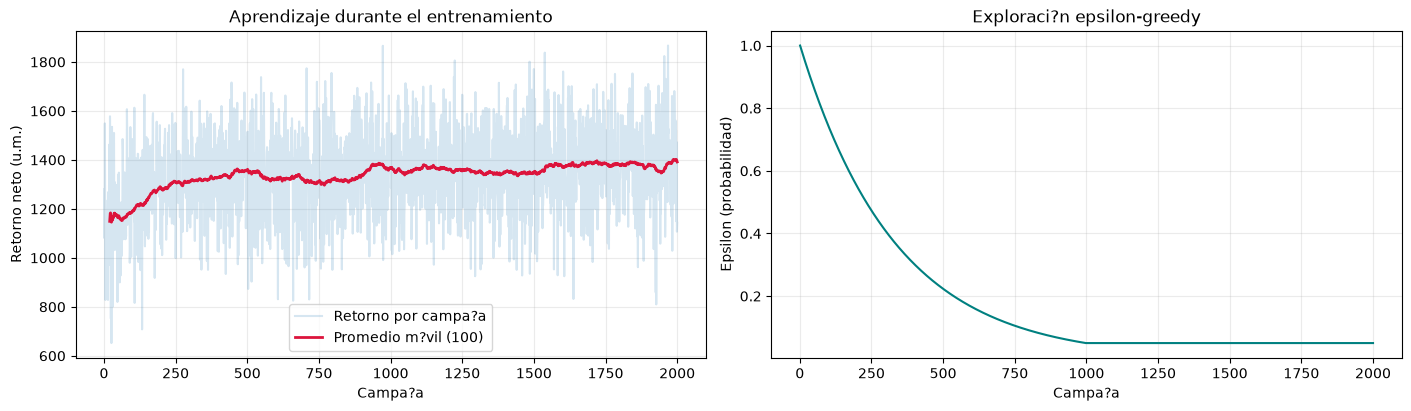

**Interpretaci?n.** Cada punto tenue es una campa?a; la l?nea roja suaviza 100 campa?as para mostrar la tendencia. El promedio de las primeras 100 es 1191.69 u.m. y el de las ?ltimas 100 es 1391.72 u.m. Epsilon cae de 1.00 a 0.05: al principio prueba acciones y despu?s explota m?s la tabla Q. Las campa?as siguen variando por la aleatoriedad de los clientes y las compras.

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
rolling = train_history["return"].rolling(100, min_periods=20).mean()
axes[0].plot(train_history["episode"], train_history["return"],
             alpha=0.18, label="Retorno por campa?a")
axes[0].plot(train_history["episode"], rolling, color="crimson",
             linewidth=2, label="Promedio m?vil (100)")
axes[0].set(title="Aprendizaje durante el entrenamiento",
            xlabel="Campa?a", ylabel="Retorno neto (u.m.)")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(train_history["episode"], train_history["epsilon"], color="teal")
axes[1].set(title="Exploraci?n epsilon-greedy",
            xlabel="Campa?a", ylabel="Epsilon (probabilidad)")
axes[1].grid(alpha=0.25)
plt.show()
first_mean = train_history["return"].head(100).mean()
last_mean = train_history["return"].tail(100).mean()
display(Markdown(
    f"**Interpretaci?n.** Cada punto tenue es una campa?a; la l?nea roja suaviza "
    f"100 campa?as para mostrar la tendencia. El promedio de las primeras 100 "
    f"es {first_mean:.2f} u.m. y el de las ?ltimas 100 es {last_mean:.2f} u.m. "
    f"Epsilon cae de {train_history['epsilon'].iloc[0]:.2f} a "
    f"{train_history['epsilon'].iloc[-1]:.2f}: al principio prueba acciones y "
    f"despu?s explota m?s la tabla Q. Las campa?as siguen variando por la "
    f"aleatoriedad de los clientes y las compras."))

## 5. Pol?tica aprendida y cobertura

Terminando el entrenamiento se extrae pi(s) = argmax entre las acciones costeables. Se muestran ejemplos **visitados** y los valores Q, para evitar interpretar estados nunca vistos como conocimiento aprendido. La tabla de cobertura informa cu?ntas combinaciones estado?acci?n no se probaron o se probaron menos de cinco veces.

In [15]:
policy_rows = []
for state in STATES:
    if state[3] == "ZERO":
        continue
    s_idx = STATE_TO_INDEX[state]
    policy_rows.append({
        "bucket_cliente": state[0], "fuente": state[1],
        "respuesta_anterior": state[2], "bucket_presupuesto": state[3],
        "accion_optima": greedy_action(Q, state),
        "visitas_estado": int(state_action_visits[s_idx].sum()),
        **{f"Q_{action}": Q[s_idx, ACTION_TO_INDEX[action]]
           for action in SELLER_ACTIONS},
    })
policy_df = pd.DataFrame(policy_rows)
visited_policy = policy_df[policy_df["visitas_estado"] >= 5].copy()
examples = (visited_policy.sort_values("visitas_estado", ascending=False)
            .groupby("accion_optima", group_keys=False).head(3))
display(examples[["bucket_cliente", "fuente", "respuesta_anterior",
                  "bucket_presupuesto", "accion_optima", "visitas_estado"]])
print("Acciones elegidas en estados visitados:")
display(visited_policy["accion_optima"].value_counts().rename_axis("acci?n").to_frame("estados"))

feasible_pairs = [(STATE_TO_INDEX[s], ACTION_TO_INDEX[a])
                  for s in STATES for a in available_actions(s)]
counts = np.array([state_action_visits[i, j] for i, j in feasible_pairs])
print(f"Pares estado-acci?n factibles: {len(counts)}")
print(f"Nunca probados: {(counts == 0).sum()}; con menos de 5 visitas: {(counts < 5).sum()}")
display(pd.crosstab(visited_policy["bucket_presupuesto"],
                    visited_policy["accion_optima"])
        .reindex(BUDGET_BANDS, fill_value=0))
display(Markdown(
    "**Interpretaci?n.** La tabla de ejemplos muestra d?nde la pol?tica recomienda "
    "descuentos, productos, lealtad o ninguna acci?n, seg?n las visitas reales. "
    "El cruce por presupuesto permite ver si la decisi?n cambia al bajar los recursos. "
    "Los pares casi nunca visitados tienen estimaciones Q menos confiables; "
    "la pol?tica desempata a favor de la acci?n de menor costo."))

,bucket_cliente,fuente,respuesta_anterior,bucket_presupuesto,accion_optima,visitas_estado
59,LOW,Display,NONE,SEVENTY_HUNDRED,SEND_DISCOUNT,4269
77,LOW,Facebook,NONE,SEVENTY_HUNDRED,NO_ACTION,4235
23,LOW,Organic,NONE,SEVENTY_HUNDRED,NO_ACTION,4123
28,LOW,Organic,PURCHASE,FORTY_SIXTYNINE,LOYALTY_REWARD,3096
82,LOW,Facebook,PURCHASE,FORTY_SIXTYNINE,NO_ACTION,3083
131,MEDIUM,Email,NONE,SEVENTY_HUNDRED,RECOMMEND_PRODUCT,3065
64,LOW,Display,PURCHASE,FORTY_SIXTYNINE,LOYALTY_REWARD,3029
95,MEDIUM,Search,NONE,SEVENTY_HUNDRED,RECOMMEND_PRODUCT,3003
29,LOW,Organic,PURCHASE,SEVENTY_HUNDRED,RECOMMEND_PRODUCT,2833
34,LOW,Organic,NO_PURCHASE,FORTY_SIXTYNINE,LOYALTY_REWARD,2116


Acciones elegidas en estados visitados:


,estados
acci?n,
RECOMMEND_PRODUCT,65
NO_ACTION,57
LOYALTY_REWARD,37
SEND_DISCOUNT,16


Pares estado-acci?n factibles: 945
Nunca probados: 234; con menos de 5 visitas: 432


accion_optima,LOYALTY_REWARD,NO_ACTION,RECOMMEND_PRODUCT,SEND_DISCOUNT
bucket_presupuesto,,,,
ZERO,0,0,0,0
ONE,0,2,3,0
TWO_THREE,2,4,5,0
FOUR_FOURTEEN,4,6,12,6
FIFTEEN_THIRTYNINE,11,13,16,1
FORTY_SIXTYNINE,11,11,18,5
SEVENTY_HUNDRED,9,21,11,4


**Interpretaci?n.** La tabla de ejemplos muestra d?nde la pol?tica recomienda descuentos, productos, lealtad o ninguna acci?n, seg?n las visitas reales. El cruce por presupuesto permite ver si la decisi?n cambia al bajar los recursos. Los pares casi nunca visitados tienen estimaciones Q menos confiables; la pol?tica desempata a favor de la acci?n de menor costo.

## 6. Evaluaci?n en campa?as nuevas

Se comparan **300 campa?as nuevas por pol?tica** con las mismas semillas iniciales para: selecci?n aleatoria uniforme entre acciones costeables, una regla fija que usa el estado observable y la pol?tica Q codiciosa (epsilon = 0). Durante esta evaluaci?n Q permanece congelada. Se reportan retorno promedio y desviaci?n est?ndar, ventas, ingreso, costo comercial, presupuesto utilizado e interacciones promedio.

In [16]:
EVAL_EPISODES = 300
EVAL_SEED = 50000

def random_policy(state, rng):
    options = available_actions(state)
    return options[int(rng.integers(len(options)))]

def fixed_policy(state, rng=None):
    bucket, source, previous, budget = state
    options = available_actions(state)
    if previous == "PURCHASE":
        choice = NO_ACTION
    elif bucket == "LOW" and source in ("Search", "Display"):
        choice = SEND_DISCOUNT
    elif source in ("Organic", "Facebook"):
        choice = RECOMMEND_PRODUCT
    elif source == "Email":
        choice = LOYALTY_REWARD
    else:
        choice = NO_ACTION
    return choice if choice in options else NO_ACTION

def q_policy(state, rng=None, q_table=None):
    return greedy_action(Q if q_table is None else q_table, state)

def evaluate_seller(policy_fn, episodes=EVAL_EPISODES, seed=EVAL_SEED,
                    policy_name="Pol?tica"):
    env = MesaSellerEnv()
    rng = np.random.default_rng(seed + 900000)
    rows = []
    for campaign in range(1, episodes + 1):
        state = env.reset(seed=seed + campaign)
        total_return = total_revenue = total_cost = 0.0
        sales = 0
        action_counts = {action: 0 for action in SELLER_ACTIONS}
        while True:
            action = policy_fn(state, rng)
            state, reward, done, info = env.step(action)
            total_return += reward
            total_revenue += info["revenue"]
            total_cost += info["action_cost"]
            sales += int(info["purchased"])
            action_counts[action] += 1
            if done:
                break
        rows.append({
            "policy": policy_name, "campaign": campaign, "return": total_return,
            "sales": sales, "revenue": total_revenue, "action_cost": total_cost,
            "budget_used": env.initial_budget - env.budget_remaining,
            "interactions": env.interaction_count,
            **{f"n_{action}": action_counts[action] for action in SELLER_ACTIONS},
        })
    return pd.DataFrame(rows)

def summarize_evaluation(evaluation):
    return evaluation.groupby("policy", sort=False).agg(
        return_mean=("return", "mean"),
        return_std=("return", "std"),
        sales_mean=("sales", "mean"),
        revenue_mean=("revenue", "mean"),
        action_cost_mean=("action_cost", "mean"),
        budget_used_mean=("budget_used", "mean"),
        interactions_mean=("interactions", "mean"),
    )

q_before_evaluation = Q.copy()
eval_random = evaluate_seller(random_policy, policy_name="Aleatoria")
eval_fixed = evaluate_seller(fixed_policy, policy_name="Regla fija")
eval_q = evaluate_seller(q_policy, policy_name="Q-learning")
evaluation = pd.concat([eval_random, eval_fixed, eval_q], ignore_index=True)
summary = summarize_evaluation(evaluation)
assert np.array_equal(Q, q_before_evaluation), "La evaluaci?n modific? Q"
assert (evaluation["interactions"] <= MAX_INTERACTIONS).all()
assert (evaluation["budget_used"] <= INITIAL_BUDGET).all()
display(summary.round(2))

,return_mean,return_std,sales_mean,revenue_mean,action_cost_mean,budget_used_mean,interactions_mean
policy,,,,,,,
Aleatoria,1161.56,193.12,33.94,1259.12,97.56,97.56,56.17
Regla fija,1336.23,167.26,35.73,1388.39,52.15,52.15,60.00
Q-learning,1356.07,168.21,36.32,1411.84,55.77,55.77,60.00


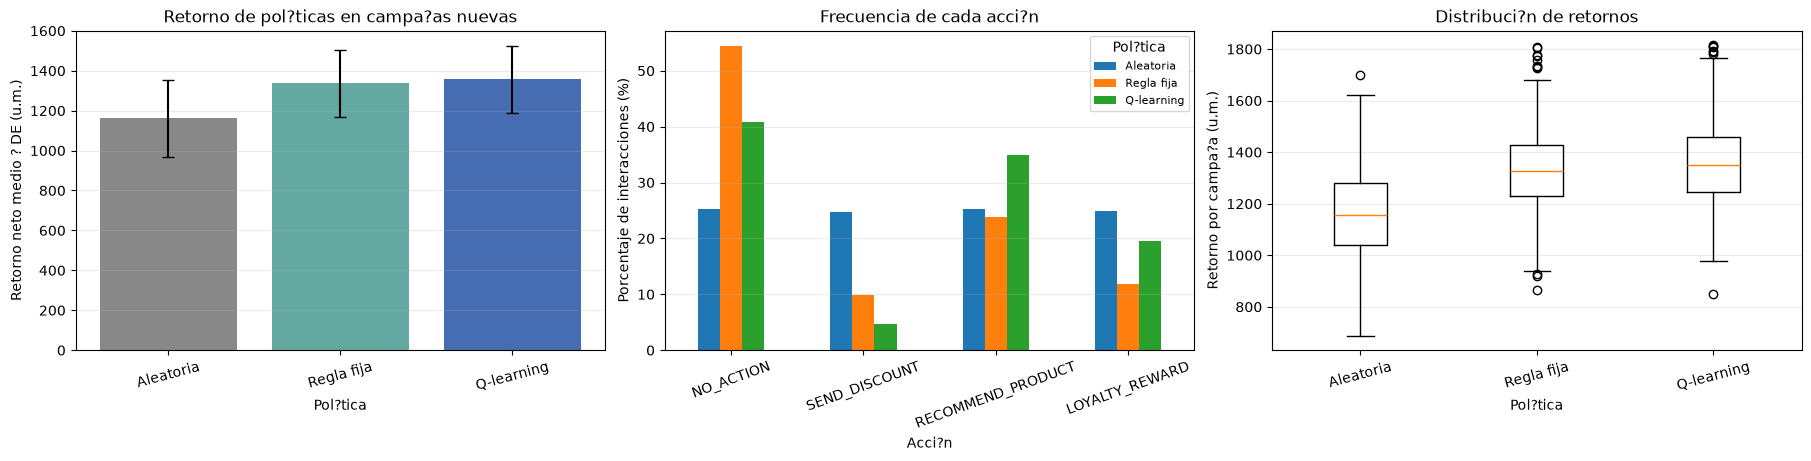

**Interpretaci?n.** La primera gr?fica compara retorno medio; las barras de error son una desviaci?n est?ndar y muestran la variaci?n entre campa?as. Q-learning obtiene +194.50 u.m. frente a la aleatoria. La segunda gr?fica muestra que su acci?n m?s usada es **NO_ACTION**; la tercera permite ver la dispersi?n y los casos extremos, que el promedio por s? solo no muestra.

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)
names = summary.index.tolist()
axes[0].bar(names, summary["return_mean"],
            yerr=summary["return_std"], capsize=4, color=["#888888", "#63A9A2", "#466CB2"])
axes[0].set(title="Retorno de pol?ticas en campa?as nuevas",
            xlabel="Pol?tica", ylabel="Retorno neto medio ? DE (u.m.)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.25)

freq = pd.DataFrame(index=names)
for action in SELLER_ACTIONS:
    freq[action] = [100 * evaluation.loc[evaluation["policy"] == name,
                         f"n_{action}"].sum() /
                    evaluation.loc[evaluation["policy"] == name, "interactions"].sum()
                    for name in names]
freq.T.plot.bar(ax=axes[1], rot=20)
axes[1].set(title="Frecuencia de cada acci?n",
            xlabel="Acci?n", ylabel="Porcentaje de interacciones (%)")
axes[1].legend(title="Pol?tica", fontsize=8)
axes[1].grid(axis="y", alpha=0.25)

axes[2].boxplot([evaluation.loc[evaluation["policy"] == name, "return"]
                 for name in names], tick_labels=names)
axes[2].set(title="Distribuci?n de retornos",
            xlabel="Pol?tica", ylabel="Retorno por campa?a (u.m.)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(axis="y", alpha=0.25)
plt.show()
best_action = freq.loc["Q-learning"].idxmax()
difference = summary.loc["Q-learning", "return_mean"] - summary.loc["Aleatoria", "return_mean"]
display(Markdown(
    f"**Interpretaci?n.** La primera gr?fica compara retorno medio; las barras de "
    f"error son una desviaci?n est?ndar y muestran la variaci?n entre campa?as. "
    f"Q-learning obtiene {difference:+.2f} u.m. frente a la aleatoria. "
    f"La segunda gr?fica muestra que su acci?n m?s usada es **{best_action}**; "
    f"la tercera permite ver la dispersi?n y los casos extremos, que el promedio "
    f"por s? solo no muestra."))

## 7. Experimento adicional: tasa de aprendizaje

Se cambia solo ? de 0.10 a 0.30. Ambas corridas usan las mismas semillas de entrenamiento, ? y calendario de exploraci?n; se eval?an sobre las **mismas 300 campa?as nuevas**. Un ? mayor reacciona m?s r?pido a recompensas recientes, pero puede fluctuar m?s en este simulador estoc?stico. La comparaci?n emp?rica indica cu?l convino aqu?; un solo experimento no demuestra que el valor sea universalmente mejor.

,return_mean,return_std,sales_mean,revenue_mean,action_cost_mean,budget_used_mean,interactions_mean
policy,,,,,,,
Q-learning ?=0.10,1356.07,168.21,36.32,1411.84,55.77,55.77,60.0
Q-learning ?=0.30,1327.61,161.04,36.48,1395.37,67.76,67.76,60.0


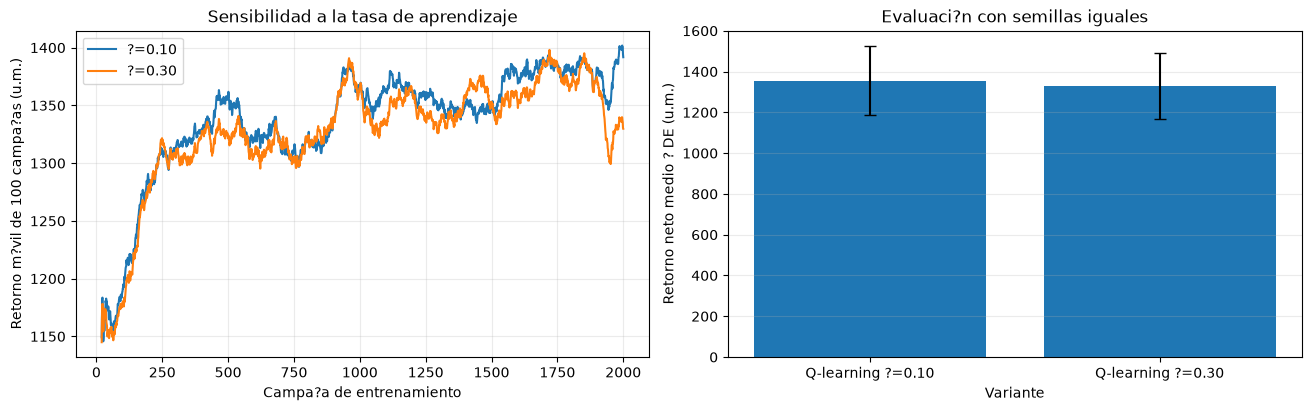

**Interpretaci?n.** Con ?=0.30 el retorno medio de evaluaci?n cambia -28.45 u.m. frente a ?=0.10. Las curvas muestran c?mo evolucion? cada entrenamiento; las barras comparan campa?as nunca usadas para actualizar Q. El resultado puede variar con otra semilla.

In [18]:
ALPHA_ALTERNATIVE = 0.30
Q_alt, train_alt, _, visits_alt = train_q_learning(
    episodes=TRAIN_EPISODES, alpha=ALPHA_ALTERNATIVE,
    seed=TRAIN_SEED, keep_transitions=False)
eval_alt = evaluate_seller(
    lambda state, rng: q_policy(state, rng, q_table=Q_alt),
    episodes=EVAL_EPISODES, seed=EVAL_SEED, policy_name="Q-learning ?=0.30")
experiment_eval = pd.concat([eval_q.assign(policy="Q-learning ?=0.10"), eval_alt],
                            ignore_index=True)
experiment_summary = summarize_evaluation(experiment_eval)
display(experiment_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(train_history["episode"],
             train_history["return"].rolling(100, min_periods=20).mean(),
             label="?=0.10")
axes[0].plot(train_alt["episode"],
             train_alt["return"].rolling(100, min_periods=20).mean(),
             label="?=0.30")
axes[0].set(title="Sensibilidad a la tasa de aprendizaje",
            xlabel="Campa?a de entrenamiento",
            ylabel="Retorno m?vil de 100 campa?as (u.m.)")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].bar(experiment_summary.index, experiment_summary["return_mean"],
            yerr=experiment_summary["return_std"], capsize=4)
axes[1].set(title="Evaluaci?n con semillas iguales",
            xlabel="Variante", ylabel="Retorno neto medio ? DE (u.m.)")
axes[1].grid(axis="y", alpha=0.25)
plt.show()
alt_difference = (experiment_summary.loc["Q-learning ?=0.30", "return_mean"] -
                  experiment_summary.loc["Q-learning ?=0.10", "return_mean"])
display(Markdown(
    f"**Interpretaci?n.** Con ?=0.30 el retorno medio de evaluaci?n cambia "
    f"{alt_difference:+.2f} u.m. frente a ?=0.10. Las curvas muestran c?mo "
    f"evolucion? cada entrenamiento; las barras comparan campa?as nunca usadas "
    f"para actualizar Q. El resultado puede variar con otra semilla."))

## 8. Discusi?n y l?mites

La siguiente celda responde las preguntas de la entrega usando las m?tricas producidas arriba. El entorno es **sint?tico**: las probabilidades de compra, las reacciones y los precios fueron definidos por c?digo, no estimados de clientes reales. El bucket de conversi?n usa un puntaje heur?stico observable; no es una red neuronal ni una llamada a GCP.

In [ ]:
q_return = summary.loc["Q-learning", "return_mean"]
random_return = summary.loc["Aleatoria", "return_mean"]
preferred = freq.loc["Q-learning"].sort_values(ascending=False)
sparse_states = int((policy_df["visitas_estado"] < 5).sum())
budget_counts = pd.crosstab(visited_policy["bucket_presupuesto"],
                            visited_policy["accion_optima"])
budget_text = ", ".join(
    f"{band}: {budget_counts.loc[band].idxmax()}"
    for band in budget_counts.index if budget_counts.loc[band].sum() > 0)
display(Markdown(f'''   
1. **?Supera a la aleatoria?** Retorno medio Q = {q_return:.2f} u.m.; aleatoria = {random_return:.2f} u.m. Diferencia = {q_return-random_return:+.2f} u.m. Las desviaciones est?ndar y cajas muestran cu?nto var?an las campa?as.
2. **?Qu? acciones usa?** La m?s frecuente en evaluaci?n es **{preferred.index[0]}** ({preferred.iloc[0]:.1f}% de sus interacciones); la tabla y la gr?fica muestran las dem?s.
3. **?Qu? efecto tiene el presupuesto?** El agente solo puede pagar acciones disponibles. En los estados visitados, la acci?n predominante por rango es: {budget_text}. Los rangos con pocas visitas requieren cautela.
4. **?Es suficiente el estado?** Resume conversi?n, fuente, respuesta previa y presupuesto. Omite confianza, dinero, rasgos y toda la historia del cliente, de modo que dos situaciones con el mismo estado observable pueden reaccionar distinto; es una aproximaci?n parcialmente observable.
5. **?Hay estados poco visitados?** {sparse_states} de {len(policy_df)} estados de decisi?n recibieron menos de cinco visitas; {(counts < 5).sum()} de {len(counts)} pares factibles estado?acci?n tambi?n. Sus valores Q son menos confiables.
6. **?C?mo afecta la exploraci?n?** Epsilon comienza en {EPSILON_START:.2f} y baja hasta {EPSILON_MIN:.2f}. Al inicio se prueban acciones; al final se usa con m?s frecuencia lo aprendido. Si baja demasiado pronto, algunos pares apenas se visitan.
7. **?La recompensa representa el objetivo?** Mide ingreso cobrado menos gasto comercial y coincide con el retorno neto simulado. No incluye margen de producto, devoluciones, costo de adquisici?n ni valor futuro del cliente.
8. **?Qu? puede volver poco realista la pol?tica?** Probabilidades, perfiles, preferencias y reacciones fueron programados; las fuentes se muestrean de forma simple y cada campa?a simula solo 20 clientes. No hay inventario ni cambios del mercado.
9. **?Qu? cambiar?amos en un caso real?** Usar ventas y costos reales, estimar el puntaje con datos observados, a?adir margen y restricciones, validar fuera de muestra y probar primero con experimentos controlados.
'''))


1. **?Supera a la aleatoria?** Retorno medio Q = 1356.07 u.m.; aleatoria = 1161.56 u.m. Diferencia = +194.50 u.m. Las desviaciones est?ndar y cajas muestran cu?nto var?an las campa?as.
2. **?Qu? acciones usa?** La m?s frecuente en evaluaci?n es **NO_ACTION** (40.8% de sus interacciones); la tabla y la gr?fica muestran las dem?s.
3. **?Qu? efecto tiene el presupuesto?** El agente solo puede pagar acciones disponibles. En los estados visitados, la acci?n predominante por rango es: FIFTEEN_THIRTYNINE: RECOMMEND_PRODUCT, FORTY_SIXTYNINE: RECOMMEND_PRODUCT, FOUR_FOURTEEN: RECOMMEND_PRODUCT, ONE: RECOMMEND_PRODUCT, SEVENTY_HUNDRED: NO_ACTION, TWO_THREE: RECOMMEND_PRODUCT. Los rangos con pocas visitas requieren cautela.
4. **?Es suficiente el estado?** Resume conversi?n, fuente, respuesta previa y presupuesto. Omite confianza, dinero, rasgos y toda la historia del cliente, de modo que dos situaciones con el mismo estado observable pueden reaccionar distinto; es una aproximaci?n parcialmente observable.
5. **?Hay estados poco visitados?** 95 de 270 estados de decisi?n recibieron menos de cinco visitas; 432 de 945 pares factibles estado?acci?n tambi?n. Sus valores Q son menos confiables.
6. **?C?mo afecta la exploraci?n?** Epsilon comienza en 1.00 y baja hasta 0.05. Al inicio se prueban acciones; al final se usa con m?s frecuencia lo aprendido. Si baja demasiado pronto, algunos pares apenas se visitan.
7. **?La recompensa representa el objetivo?** Mide ingreso cobrado menos gasto comercial y coincide con el retorno neto simulado. No incluye margen de producto, devoluciones, costo de adquisici?n ni valor futuro del cliente.
8. **?Qu? puede volver poco realista la pol?tica?** Probabilidades, perfiles, preferencias y reacciones fueron programados; las fuentes se muestrean de forma simple y cada campa?a simula solo 20 clientes. No hay inventario ni cambios del mercado.
9. **?Qu? cambiar?amos en un caso real?** Usar ventas y costos reales, estimar el puntaje con datos observados, a?adir margen y restricciones, validar fuera de muestra y probar primero con experimentos controlados.


## 9. Tabla Q y preparaci?n de entregables

El notebook es autocontenido. El DataFrame transitions_df contiene el dataset completo y q_table_df contiene la tabla Q aprendida. **Por la indicaci?n de mantener todo en este notebook, las l?neas de exportaci?n a CSV est?n comentadas**: descom?ntalas si el profesor pide subir los CSV por separado. La primera celda funciona como gu?a de ejecuci?n; no se crean README ni otros archivos aqu?.

**C?mo correrlo en Colab:** subir este notebook, seleccionar Runtime ? Run all, esperar a que terminen las dos corridas de entrenamiento y revisar las tablas y gr?ficas en orden. Mesa se instala en la primera celda. No se requieren credenciales ni GCP.

In [20]:
q_table_df = pd.DataFrame(Q, columns=[f"Q_{action}" for action in SELLER_ACTIONS])
q_table_df.insert(0, "state", STATES)
q_table_df["visits"] = state_action_visits.sum(axis=1)
display(q_table_df.sort_values("visits", ascending=False).head(10))
print("Filas en transitions_df:", len(transitions_df))
print("Filas en q_table_df:", len(q_table_df))
# Para entregar los CSV por separado, descomentar estas dos l?neas:
# transitions_df.to_csv("mesa_transitions.csv", index=False)
# q_table_df.to_csv("mesa_q_table.csv", index=False)

,state,Q_NO_ACTION,Q_SEND_DISCOUNT,Q_RECOMMEND_PRODUCT,Q_LOYALTY_REWARD,visits
69,"(LOW, Display, NONE, SEVENTY_HUNDRED)",381.894966,400.891788,384.070866,378.968077,4269
90,"(LOW, Facebook, NONE, SEVENTY_HUNDRED)",415.671083,383.260786,389.406610,381.668101,4235
27,"(LOW, Organic, NONE, SEVENTY_HUNDRED)",407.428503,386.401646,387.274713,388.482445,4123
33,"(LOW, Organic, PURCHASE, FORTY_SIXTYNINE)",209.865793,207.453144,224.080479,262.104018,3096
96,"(LOW, Facebook, PURCHASE, FORTY_SIXTYNINE)",268.180412,206.447932,225.815419,230.776475,3083
153,"(MEDIUM, Email, NONE, SEVENTY_HUNDRED)",378.817094,378.706190,411.097371,386.019709,3065
75,"(LOW, Display, PURCHASE, FORTY_SIXTYNINE)",230.694822,235.267855,234.244486,263.454427,3029
111,"(MEDIUM, Search, NONE, SEVENTY_HUNDRED)",395.841621,372.613539,409.619092,387.309196,3003
76,"(LOW, Display, PURCHASE, SEVENTY_HUNDRED)",408.963947,369.802314,377.743970,371.014948,2836
34,"(LOW, Organic, PURCHASE, SEVENTY_HUNDRED)",376.316877,342.590866,406.861141,377.387424,2833


Filas en transitions_df: 119705
Filas en q_table_df: 315
